<a href="https://colab.research.google.com/github/Lorenxo-Padova/NaturalLanguageProcessingProject/blob/main/Baggio_Berlese_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retrieval-Augmented Generation (RAG) Project

Final NLP project on RAG by:  
- Baggio Davide (2122547), Computer Engineering curriculum ARTIFICIAL INTELLIGENCE and ROBOTICS
- Berlese Lorenzo (2163824), Computer Engineering curriculum HIGH PERFORMANCE AND BIG DATA COMPUTING


## Implementation based on Italian Legal Corpus dataset.

**Specifications:**
- *Embedding: `intfloat/multilingual-e5-base`*
- *Vector Store: `faiss-cpu`*
- *Generator LLM: `Qwen3 - 8B (with 4bit quantization)`*
- *Judge LLM: `Google Gemini 3.1 flash lite`*

## 1. Environment Setup

In [ ]:
!pip install -q -U \
    transformers \
    tokenizers \
    accelerate \
    faiss-cpu \
    datasets \
    google-genai \
    bitsandbytes \
    gdown

#### **Pipeline Architecture & Dependencies**
The project relies on a focused stack of libraries, each powering a distinct stage of the pipeline:

**1. Retrieval & Vector Storage**
* **`transformers`**: Generates dense vector representations. It loads the embedding model to process both the source document chunks and the user queries.
* **`faiss-cpu`**: Serves as our lightweight vector database. This Facebook AI Similarity Search library indexes the chunk embeddings and performs highly efficient, NumPy-native similarity searches to retrieve the top-*N* most relevant contexts.

**2. Generation & Model Optimization**
* **`transformers`** (Hugging Face): Manages the generative component. It loads the chat LLM (`Qwen 3 - 8B`) alongside its tokenizer to run inference.
* **`bitsandbytes`**: Handles 4-bit model quantization. This reduces Qwen's memory footprint from roughly 16 GB down to about 9 GB, ensuring both the generator and embedding models fit comfortably within Google Colab's GPU limits.

**3. Evaluation**
* **`google-genai`**: Interfaces with the Gemini API. We utilize Gemini during the evaluation phase as a high-capacity model to generate the test set and serve as the "LLM-as-a-Judge."

*Note: The three core components required by the assignment—the embedding model, vector store, and quantized generator—are fully covered above. Standard utilities (NumPy, PyTorch, Matplotlib) are also used to handle routine array/tensor operations and data visualization*

In [ ]:
import os
import json

from datasets import load_dataset

import torch
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, BitsAndBytesConfig

import matplotlib.pyplot as plt
import numpy as np

from google.colab import userdata
from google import genai

In [ ]:
CACHE_DIR = "./cache"
DATA_CACHE = os.path.join(CACHE_DIR, "datasets")
MODEL_CACHE = os.path.join(CACHE_DIR, "models")

for path in [DATA_CACHE, MODEL_CACHE]:
    os.makedirs(path, exist_ok=True)

print(f"Cache directories initialized at: {CACHE_DIR}")

Cache directories initialized at: ./cache


In [ ]:
os.environ['HF_HOME'] = CACHE_DIR
os.environ['TRANSFORMERS_CACHE'] = MODEL_CACHE
os.environ['HF_DATASETS_CACHE'] = DATA_CACHE

In [ ]:
DATASET_NAME = "dossier-legal/italian-legal-corpus"
EMBEDDING_MODEL_ID = "intfloat/multilingual-e5-base"
GENERATOR_MODEL_ID = "Qwen/Qwen3-8B"

print("Environment and libraries initialized.")

Environment and libraries initialized.


## 2. Domain and dataset

A comprehensive corpus of Italian legal texts from 4 open-data sources, designed for training and evaluating legal NLP models.

|Source | Description | Documents|
|-----------|--------------|-------------|
|Normattiva | All Italian national legislation (1861-2026) | ~300K|
|Corte Costituzionale | Constitutional Court decisions (1956-2026) | ~18K|
|OpenGA | Administrative justice metadata | ~100K|
|EUR-Lex | EU legislation in Italian | ~50K|

---

|Field|Type|Description|
|-----------|--------------|-------------|
|id|string|Globally unique ID ({{source}}_{{specific_id}})|
|source|string|One of: normattiva, corte_costituzionale, openga, eurlex|
|doc_type|string|Document type (legislation, decision, regulation, etc.)|
|title|string|Human-readable title|
|date|string?|ISO 8601 date (YYYY-MM-DD)|
|text|string|Full cleaned text|
|authority|string?|Issuing authority|
|number|string?|Document number|
|year|int?|Publication year|
|ecli|string?|ECLI identifier (court decisions)|
|text_length|int|Character count of text field|
|language|string|Always "it"|

---

In this specific case we decided to eliminate some columns that will act as noise during the retrieval such as id, date, text_length...

Instead we then create a new field in order to concatenate important information that are much useful for information retrieval.

We also reduced the number of documents to 5000 because of hardware limitations in Colab.


## 3. Data preparation

In [ ]:
ds = load_dataset(DATASET_NAME, cache_dir=DATA_CACHE).remove_columns(["id", "date", "number", "year", "ecli", "subject_area", "references", "url", "language"])
print(f"Loaded dataset with {len(ds['train'])} train samples.")

README.md:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

Loaded dataset with 347252 train samples.


In [ ]:
def concatenate_fields(example):
    combined = (
        f"{str(example.get('doc_type', ''))}\n"
        f"{str(example.get('authority', ''))}\n"
        f"{str(example.get('title', ''))}\n"
        f"{str(example.get('text', ''))}"
    )
    return {"combined_text": combined}

In [ ]:
validation_subset = ds["validation"].shuffle(seed=42).select(range(min(5000, len(ds["validation"]))))
validation_subset = validation_subset.map(concatenate_fields)

## 4. Embeddings Generation

In [ ]:
# FOLDER CONTAINING PRE-BUILT KNOWLEDGE BASE AND TEST SETS

!gdown --folder "https://drive.google.com/drive/folders/1LaXtzHpxPCpVzjNyUhbxfeRIuTvJYERU"

Retrieving folder contents
Processing file 1EP2v1pMkpD2V5GweIW5CJA877VxflfoH dist.json
Processing file 184fhmwu-JJFx7e4GwN7ec-HKfRki95YQ eval_results.json
Processing file 1E4sJtRbQWRh3iTjXXK4-mAR6FWC4UhV- knowledge_base_chunks.json
Processing file 1NhkexRgrr5EET79RiAdWBwIpRYBqYDci test_set.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1EP2v1pMkpD2V5GweIW5CJA877VxflfoH
To: /content/NLP - RAG/dist.json
100% 6.00/6.00 [00:00<00:00, 23.0kB/s]
Downloading...
From: https://drive.google.com/uc?id=184fhmwu-JJFx7e4GwN7ec-HKfRki95YQ
To: /content/NLP - RAG/eval_results.json
100% 15.8k/15.8k [00:00<00:00, 54.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1E4sJtRbQWRh3iTjXXK4-mAR6FWC4UhV-
From (redirected): https://drive.google.com/uc?id=1E4sJtRbQWRh3iTjXXK4-mAR6FWC4UhV-&confirm=t&uuid=2bea22d3-f9b1-4ef5-95c9-80e5765337e6
To: /content/NLP - RAG/knowledge_base_ch

In [ ]:
# RUN THIS CELL ONLY IF YOU WANT TO LOAD LATEST KNOWLEDGE BASE

with open("NLP - RAG/knowledge_base.json", "r", encoding="utf-8") as f:
    knowledge_base = json.load(f)

In [ ]:
embed_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_ID, trust_remote_code=True)
embed_model = AutoModel.from_pretrained(EMBEDDING_MODEL_ID, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")
embed_model.eval()

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=Tru

In [ ]:
# RUN THIS CELL ONLY IF YOU HAVEN'T LOADED KNOWLEDGE BASE YET AND WANT TO RECOMPUTE IT (~20 MINUTES)

knowledge_base = []

print("Generating embeddings for knowledge base...")

for i, document in tqdm(enumerate(validation_subset), total=len(validation_subset), desc="Embedding Progress"):
    inputs = embed_tokenizer(
        document['combined_text'],
        max_length=512,
        truncation=True,
        return_overflowing_tokens=True,
        stride=50,
        return_tensors="pt",
        padding=True
    ).to(embed_model.device)

    num_segments = inputs['input_ids'].shape[0]

    for j in range(num_segments):
        segment_inputs = {
            'input_ids': inputs['input_ids'][j].unsqueeze(0),
            'attention_mask': inputs['attention_mask'][j].unsqueeze(0)
        }

        with torch.no_grad():
            model_output = embed_model(**segment_inputs)
            hidden_states = model_output.last_hidden_state

        mask = segment_inputs['attention_mask'].unsqueeze(-1).expand(hidden_states.size()).float()
        pooled_embed = torch.sum(hidden_states * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
        embedding_vector = pooled_embed.detach().cpu().numpy().astype(np.float32)

        faiss.normalize_L2(embedding_vector)

        knowledge_base.append({
            'text': embed_tokenizer.decode(segment_inputs['input_ids'][0], skip_special_tokens=True),
            'metadata': {
                'doc_type': document.get('doc_type', ''),
                'authority': document.get('authority', ''),
                'title': document.get('title', '')
            },
            'embedding': embedding_vector[0].tolist(),
            'encoded_text': segment_inputs['input_ids'][0].tolist()
        })

Generating embeddings for knowledge base...


Embedding Progress: 100%|██████████| 5000/5000 [20:22<00:00,  4.09it/s]


In [ ]:
del ds

In [ ]:
with open("knowledge_base.json", "w", encoding="utf-8") as f:
    json.dump(knowledge_base, f, ensure_ascii=False, indent=4)

## 5. Data profiling

--- Dataset Statistics ---
Total Documents: 5000
Average Length: 10930.52 characters
Median Length: 1707.5 characters
Min/Max Length: 169 / 3691121 characters


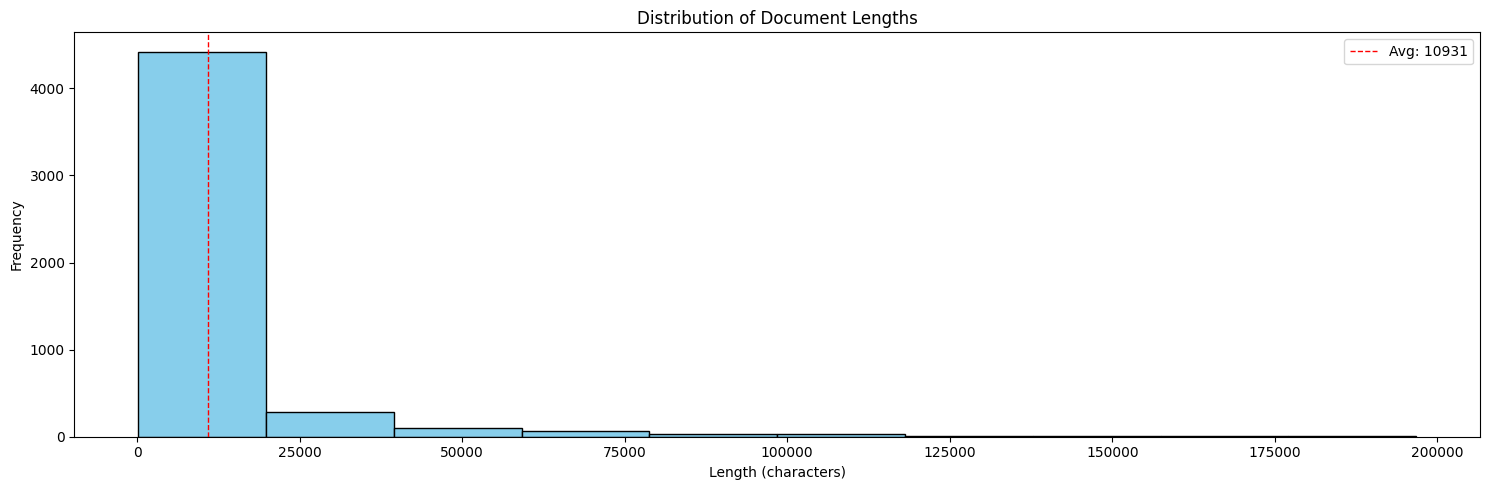

In [ ]:
doc_lengths = [len(doc['combined_text']) for doc in validation_subset]

avg_len = np.mean(doc_lengths)
median_len = np.median(doc_lengths)
max_len = np.max(doc_lengths)
min_len = np.min(doc_lengths)

print(f"--- Dataset Statistics ---")
print(f"Total Documents: {len(doc_lengths)}")
print(f"Average Length: {avg_len:.2f} characters")
print(f"Median Length: {median_len} characters")
print(f"Min/Max Length: {min_len} / {max_len} characters")

fig, axes = plt.subplots(1, 1, figsize=(15, 5))

doc_lengths = [x for x in doc_lengths if x <= 200000]

axes.hist(doc_lengths, bins=10, color='skyblue', edgecolor='black')
axes.axvline(avg_len, color='red', linestyle='dashed', linewidth=1, label=f'Avg: {avg_len:.0f}')
axes.set_title('Distribution of Document Lengths')
axes.set_xlabel('Length (characters)')
axes.set_ylabel('Frequency')
axes.legend()

plt.tight_layout()
plt.show()

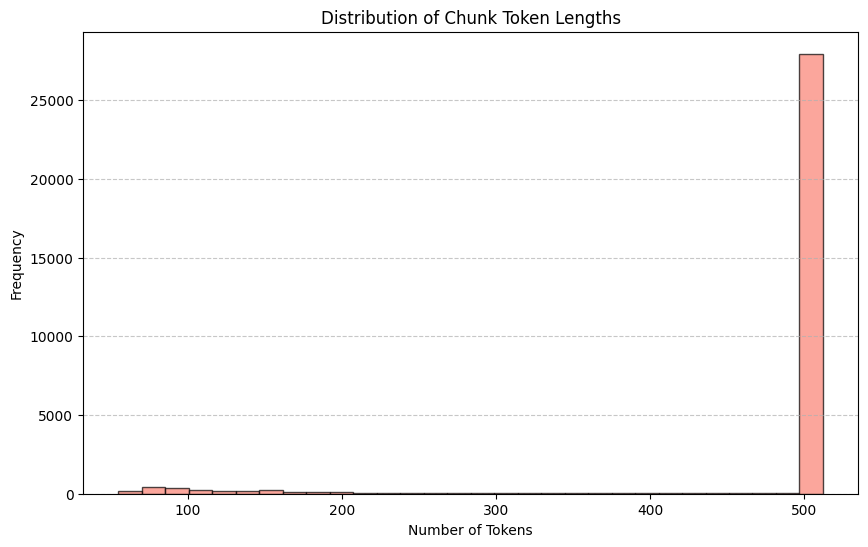

Average tokens per chunk: 481.86
Max tokens in a chunk: 512
Min tokens in a chunk: 55


In [ ]:
chunk_token_counts = [len(chunk["encoded_text"]) for chunk in knowledge_base]

plt.figure(figsize=(10, 6))
plt.hist(chunk_token_counts, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Distribution of Chunk Token Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tokens per chunk: {sum(chunk_token_counts)/len(chunk_token_counts):.2f}")
print(f"Max tokens in a chunk: {max(chunk_token_counts)}")
print(f"Min tokens in a chunk: {min(chunk_token_counts)}")

The left tail of the distribution is due to the presence in the dataset of documents of size lower than 512 tokens, such as some TAR (Tribunale Amministrativo Regionale) decisions.

## 6. Vector Store Setup

In [ ]:
# --- FAISS Indexing ---
if knowledge_base:
    dim = len(knowledge_base[0]['embedding'])
    index = faiss.IndexFlatIP(dim)
    embeddings_array = np.array([chunk['embedding'] for chunk in knowledge_base], dtype=np.float32)
    index.add(embeddings_array)
    print(f'KB index built with {index.ntotal} chunks and embedding dimension {dim}')
else:
    print("No chunks created.")

KB index built with 30635 chunks and embedding dimension 768


In [ ]:
def retrieve_relevant_chunks(query_text, top_k=5):
    """
    Encodes a query into a vector and searches the FAISS index for the most
    semantically similar text chunks from the knowledge base.
    """
    inputs = embed_tokenizer(query_text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(embed_model.device)

    with torch.no_grad():
        outputs = embed_model(**inputs)
        hidden_states = outputs.last_hidden_state

    mask = inputs['attention_mask'].unsqueeze(-1).expand(hidden_states.size()).float()
    query_embedding = (torch.sum(hidden_states * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)).detach().cpu().numpy().astype(np.float32)

    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, top_k)

    return [knowledge_base[idx] for idx in indices[0]], distances

## 7. Generator LLM Setup & Inference

The generation prompt for Qwen model tries to increment the precision with numbers/dates/legal coordinates, since this was a common source of error.
The upgrade of model from Qwen 3B to Qwen 8B (though quantized), has helped reducing to 0 the error on numeric data inside the chunks.
Moreover it has been added an instruction to limit the verbosity of the responses, because this would achieve greater results on evaluation.

### Prompt Engineering & Design Choices

This section documents the prompt engineering process, design rationale and discarded alternatives. The goal was to maximise factual precision (especially for numeric and date references) while avoiding hallucinations and unnecessary verbosity.

Design goals and constraints:
- Precision-first: since legal queries often require exact citations (articles, dates, numbers), the system prompt instructs the model to rely strictly on the retrieved context and to answer `"Non so"` when the information is not present.
- Conciseness: shorter answers reduce the chance of the model introducing unsupported facts and simplify automated evaluation.
- Grounding to chunks: the prompt emphasises that the retrieved chunks are the only source of truth and forbids the use of external or latent knowledge.

Alternatives tried (and why they were discarded):
- Chain-of-thought (CoT) style prompts: produced verbose, speculative outputs and increased hallucination risk; discarded because it reduced evaluation scores on the precision metric.
- Retrieval-augmented prompts that requested multiple candidate passages and a vote: improved robustness but required more computation and introduced additional complexity to the evaluation pipeline.

If you iterate further, retain records of prompt variants and evaluation results to build an explicit prompt ablation table for reproducibility.

In [ ]:
SYSTEM_PROMPT = """
Sei un assistente per la consultazione di documenti normativi e giuridici italiani.

Il tuo compito è rispondere alla domanda utilizzando esclusivamente il contesto recuperato.

Istruzioni:

Considera il contesto come unica fonte di verità.
Non usare conoscenze pregresse.
Non integrare informazioni mancanti.
Non formulare ipotesi.
Se la risposta non è chiaramente ricavabile dal contesto, rispondi solo: "Non so".
Fornisci una risposta concisa e precisa.
I riferimenti normativi (articoli, commi, lettere, numeri, decreti e leggi) devono essere riportati esattamente come compaiono nel contesto.
Se il contesto riporta solo parte di una citazione normativa, riporta esclusivamente la parte presente.
I riferimenti temporali (date, durate, scadenze) devono essere riportati esattamente come compaiono nel contesto.
Non aggiungere commenti, avvertenze o spiegazioni extra.
"""

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer_gen = AutoTokenizer.from_pretrained(GENERATOR_MODEL_ID, cache_dir=MODEL_CACHE)
model_gen = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_ID,
    dtype="auto",
    device_map="auto",
    cache_dir=MODEL_CACHE,
    trust_remote_code=True,
    quantization_config=bnb_config
)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [ ]:
def generate_rag_response(query, retrieved_chunks):
    """
    Constructs a RAG prompt by combining the user query with context from retrieved chunks,
    and uses the Qwen LLM to generate a grounded answer.
    """
    context_block = "\n---\n".join([chunk['text'] for chunk in retrieved_chunks])

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Contesto: {context_block}\n\nDomanda: {query} \n\n Risposta"}
    ]

    tokenized_chat = tokenizer_gen.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False
    ).to(model_gen.device)

    with torch.no_grad():
        generation_output = model_gen.generate(
            **tokenized_chat,
            max_new_tokens=1000,
            temperature=0.7,
            top_p=0.8
        )

    return tokenizer_gen.decode(generation_output[0][tokenized_chat["input_ids"].shape[-1]:], skip_special_tokens=True)

## 8. Micro-Test Set Creation & Evaluation (Gemini API)

The prompt for the generation of question-gold answer pairs contains specific instructions to produce questions that are strictly related to a single document, in order to ask for a high-precision retrieval by the system.
The judge model has not been able to do it for an entire test set of 15 samples, so we have manually mixed multiple generations of question/answer pairs.
It has been explicitly asked to Gemini to generate an answer not based on its internal knowledge, but exclusively on the information present in the selected chunk, since we want to measure the capacity of the RAG system more on the retrieval part and not merely the capacity of the generating model.
We have fixed to one the number of informations asked in a question in order to see in a clearer way the work of the retrieval based on embedding similarity.

For reproducibility you can load the test set from the 'NLP - RAG' folder. In this case no GEMINI API token is needed.

In [ ]:
# RUN THIS CELL ONLY IF YOU WANT TO LOAD LATEST TEST SET

with open("NLP - RAG/test_set.json", "r", encoding="utf-8") as f:
    test_set = json.load(f)

In [ ]:
# RUN THIS CELL ONLY IF YOU HAVEN'T LOADED LATEST TEST SET YET (gemini API key required)

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

import random
test_indices = random.sample(range(len(knowledge_base)), 15)
test_set = []

print("Extracting Q/A pairs for evaluation...")
for idx in test_indices:
    chunk_text = knowledge_base[idx]['text']
    prompt = f"""
    Sei un generatore di dataset per sistemi RAG.

    Individua una singola informazione esplicita contenuta nel testo.
    Genera una domanda in italiano la cui risposta sia completamente contenuta nel testo.
    La risposta (in italiano) deve essere una citazione o una parafrasi minima dell'informazione presente nel testo.
    Non utilizzare alcuna conoscenza esterna.
    Non effettuare inferenze giuridiche.
    Non combinare informazioni provenienti da parti diverse del testo se non strettamente necessario.
    La domanda deve essere self-contained. Deve avere senso in se e per se, senza riferimenti a 'il passaggio', 'il testo', 'la seguente normativa'...
    Aggiungi sempre il soggetto esplicito della domanda.

    Restituisci soltanto JSON valido:

    {{
    "question": "...",
    "answer": "..."
    }}

    Testo:
    {chunk_text}
    """

    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=prompt
    )
    try:
        # Simple cleaning of response text if it has markdown
        clean_text = response.text.strip().strip('```json').strip('```').strip()
        qa = json.loads(clean_text)
        test_set.append({
            'question': qa['question'],
            'gold_answer': qa['answer'],
            'chunk_idx': idx
        })
    except:
        continue


with open("test_set.json", "w", encoding="utf-8") as f:
    json.dump(test_set, f, ensure_ascii=False, indent=4)

from google.colab import files
files.download("test_set.json")

print(f"Test set created with {len(test_set)} samples.")

Extracting Q/A pairs for evaluation...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test set created with 15 samples.


The evaluation prompt specifies a scale from 1 to 5 because the scale from 1 to 10 appeared too granular on the possible outputs generated.
It has been decided to limit the verbosity of the responses to grasp immediately if the system has been able to find the correct chunk and generate an answer accordingly

In [ ]:
def evaluate_answer_with_gemini(question, gold_answer, system_response):
    """
    Uses the Gemini model to evaluate the quality of a system response compared
    to a gold standard answer, returning a score and a qualitative reason.
    """
    evaluation_prompt = f"""
Sei un valutatore esperto di sistemi RAG per documenti giuridici italiani.

Il tuo compito è confrontare la risposta del sistema con la risposta corretta (gold answer) e assegnare un punteggio da 1 a 5.

Criteri di valutazione:

- 5 = risposta perfetta o quasi perfetta
- 4 = risposta corretta ma verbosa
- 3 = risposta parzialmente corretta
- 2 = prevalentemente errata
- 1 = risposta sbagliata / allucinazione / nessuna risposta

Regole:

Valuta il contenuto, non la forma.
Considera equivalenti parafrasi corrette della risposta gold.
Penalizza informazioni aggiuntive non richieste.
Penalizza fortemente affermazioni errate.
Non assegnare 5 se la risposta contiene informazioni non supportate dalla risposta gold.
Restituisci esclusivamente JSON valido.

Formato JSON:

{{
"score": <intero da 1 a 5>,
"reason": ""
}}

Domanda:
{question}

Risposta corretta:
{gold_answer}

Risposta del sistema:
{system_response}
"""
    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=evaluation_prompt
    )
    try:
        clean_text = response.text.strip().strip('```json').strip('```').strip()
        return json.loads(clean_text)
    except:
        return {'score': 0, 'reason': 'Failed to parse evaluation.'}

In case you don't want to use GEMINI API token you can load the latest evaluation files.

In [ ]:
# RUN THIS CELL ONLY IF YOU WANT TO LOAD LATEST EVALUATION RESULTS

with open("eval_results.json", "r", encoding="utf-8") as f:
    eval_results = json.load(f)

with open("dist.json", "r", encoding="utf-8") as f:
    dist = json.load(f)

In [ ]:
# RUN THIS CELL ONLY IF YOU WANT TO COMPUTE EVALUATION RESULTS (gemini API key required)

eval_results = []
dist = []
for item in test_set:
    retrieved, distances = retrieve_relevant_chunks(item['question'])
    dist.append(distances)
    print(f"Retrieved: {retrieved}")
    print(f"Distances: {distances}")
    system_ans = generate_rag_response(item['question'], retrieved)
    print(f"Question: {item['question']}")
    print(f"Gold Answer: {item['gold_answer']}")
    print(f"System Answer: {system_ans}")
    eval_res = evaluate_answer_with_gemini(item['question'], item['gold_answer'], system_ans)
    print(f"Evaluation Result: {eval_res}\n\n")
    eval_results.append({
        'question': item['question'],
        'gold': item['gold_answer'],
        'system': system_ans,
        'score': eval_res['score'],
        'reason': eval_res['reason']
    })

if eval_results:
    avg_score = sum([r['score'] for r in eval_results]) / len(eval_results)
    print(f"Average Score: {avg_score}/5")
else:
    print("No evaluation results generated.")

dist = [d.tolist()[0] for d in dist]

Retrieved: [{'text': "quantitativi di vino da tavola ottenuti tra il 1o luglio dell'anno precedente e il 15 marzo; - entro il 15 luglio, il risultato del calcolo per i quantitativi di vino da tavola ottenuti tra il 16 marzo e il 30 giugno. 4. All'atto della comunicazione o del ricevimento della notifica di cui al presente articolo, il produttore o, se del caso, l'autorità competente iscrive nei registri previsti dall'articolo 71, paragrafo 2 del regolamento (CEE) n. 822/87 i quantitativi di vino da tavola che devono essere consegnati alla distillazione. 5. Gli Stati membri raccolgono i dati ottenuti conformemente ai paragrafi 1, 2 e 3, primo trattino, e comunicano alla Commissione, entro il 15 giugno, i volumi da distillare, ripartiti per le classi di resa fissate conformemente all'articolo 5, paragrafo 1. I volumi da distillare in applicazione del paragrafo 3, secondo trattino, sono comunicati alla Commissione entro e non oltre il 15 settembre. Articolo 11 1. In caso di trasporto in c

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Question: Entro quale data gli Stati membri devono comunicare alla Commissione i quantitativi di vino indicati nei contratti di distillazione approvati?
Gold Answer: Gli Stati membri devono comunicare alla Commissione i quantitativi di vino indicati nei contratti di distillazione approvati entro e non oltre il 29 febbraio 1984.
System Answer: Entro il 29 febbraio 1984.
Evaluation Result: {'score': 5, 'reason': "La risposta del sistema è corretta, precisa e priva di informazioni superflue. Risponde direttamente alla domanda utilizzando l'esatta data indicata nella risposta gold."}


Retrieved: [{'text': 'legislation European Union Proposta di DECISIONE DEL PARLAMENTO EUROPEO E DEL CONSIGLIO relativa alla partecipazione dell\'Unione a un programma di ricerca e sviluppo avviato da vari Stati membri a sostegno delle piccole e medie imprese che effettuano attività di ricerca RELAZIONE 1. CONTESTO DELLA PROPOSTA 1.1. Obiettivi della proposta La presente proposta riguarda la partecipazione de

In [ ]:
with open("eval_results.json", "w", encoding="utf-8") as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=4)

with open("dist.json", "w", encoding="utf-8") as f:
    json.dump(dist, f, ensure_ascii=False, indent=4)

## 9. Analysis

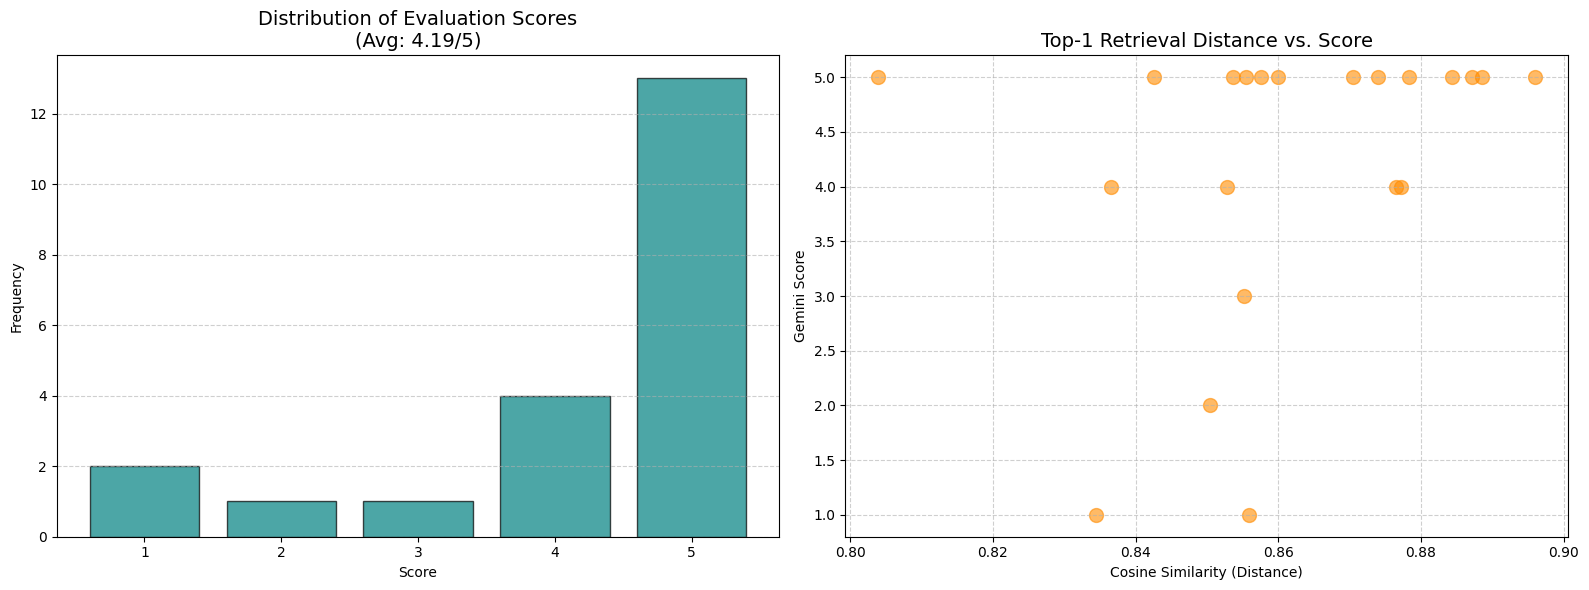

--- RAG System Performance Analysis ---
Total Samples Evaluated: 21
Average Score: 4.19 / 5.0
Success Rate (Score >= 4): 81.0%
Failure Rate (Score <= 2): 14.3%
Average Retrieval Similarity: 0.8615


In [ ]:
scores = [r['score'] for r in eval_results]
avg_score = np.mean(scores) if scores else 0
top1_distances = [d[0] for d in dist if len(d) > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unique_scores, counts = np.unique(scores, return_counts=True)
axes[0].bar(unique_scores, counts, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Distribution of Evaluation Scores\n(Avg: {avg_score:.2f}/5)', fontsize=14)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 6))
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

if len(top1_distances) == len(scores):
    axes[1].scatter(top1_distances, scores, color='darkorange', alpha=0.6, s=100)
    axes[1].set_title('Top-1 Retrieval Distance vs. Score', fontsize=14)
    axes[1].set_xlabel('Cosine Similarity (Distance)')
    axes[1].set_ylabel('Gemini Score')
    axes[1].grid(True, linestyle='--', alpha=0.6)
else:
    axes[1].hist(top1_distances, bins=15, color='darkorange', edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribution of Top-1 Retrieval Distances', fontsize=14)
    axes[1].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.show()

print(f"--- RAG System Performance Analysis ---")
print(f"Total Samples Evaluated: {len(scores)}")
print(f"Average Score: {avg_score:.2f} / 5.0")
print(f"Success Rate (Score >= 4): {(sum(1 for s in scores if s >= 4) / len(scores) * 100):.1f}%")
print(f"Failure Rate (Score <= 2): {(sum(1 for s in scores if s <= 2) / len(scores) * 100):.1f}%")
if top1_distances:
    print(f"Average Retrieval Similarity: {np.mean(top1_distances):.4f}")

## 10. Discussion

The results show a discretely good performance of the system as a whole, with the lowest scores coming from the most generic questions such as "Qual è il contingente previsto per le patate dolci, fresche, refrigerate, congelate o essiccate dal 1° gennaio al 31 dicembre?", which does not specify a clear legislative document to search for.

The similarity of the retrieved chunks from FAISS have increased when switching from first encoders (`dbmdz/bert-base-italian-xxl-cased` or `dlicari/Italian-Legal-BERT`) to second one (`intfloat/multilingual-e5-base`).
Though, this does not lead us to think that the retrieval works in a better way.In fact from the graph in the right part of the previous cell, there is not a clear dependence of the score given by Gemini with the cosine similarity registered with the first retrieved element. Keeping the previous question as a reference, the cosine similarity of the retrieved chunks has value around 0.85, which is not particularly low with respect to the other similarities.

The real improvement in evaluation has been possible to the use of a more powerful generator model and the filtering of the gemini-generated question/answer pairs.

This has lead the system to reach a score bigger than 3 for the majority of the test set.

For what concerns the dataset, we constrained the number of documents used for chunking, embedding and storing with FAISS to 5000 items, due to the hardware resources made avalaible by Colab. A possible field of improvement of this project could be the expansion of the FAISS storage up to the original size of the dataset, possibly expanding it also with the regional and comunal legislation. This would have an impact on the retrieval, since the embedding space would be more "crowded", needing for example a higher constant K of retrieved documents, possibly with the use of reranking after the initial retrieval. Moreover this scaling up would influence the time for embedding (though it has to be done just once at the beginning), while it is expected to influence less the time for storing in faiss, since it has been nearly instantaneous for the nearly 30k chunks stored in this notebook.

Moreover, our work focused on the retrieval of documents starting from a focused question on a specific legislative coordinate.
A possible future field of testing and improvement is the retrieval of documents starting from more generic user prompts covering a general area rather than a specific document.
Moreover it could be studied how the model performs with retrieval of multiple documents, either explicitly asked-for or retrieved as a byproduct of a more generic prompts.

## 11. AI usage

In this project we have been assisted by generative AI such as Gemini for some improvements in the code base.

Generative AI models have been used for optimization of the code, prompt generation or research purposes. The structure of the code and ideas are ours (influenced by RAG lecture - lab 3)

#### Some Examples
---
- Question: *"Is there a way to remove paddings from the embeddings of the chunks in order to normalize them?"*
- Answer:
```
mask = segment_inputs['attention_mask'].unsqueeze(-1).expand(hidden_states.size()).float()
pooled_embed = torch.sum(hidden_states * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
embedding_vector = pooled_embed.detach().cpu().numpy().astype(np.float32)

faiss.normalize_L2(embedding_vector)
```
---
- Question: *"Generate a simple system prompt for a RAG system specialized in italian legal documents that has to answer only 'i dont't know' in case the information is not retrieved."*
- Answer: *SYSTEM_PROMT = """You are a helpful assistant that answers questions about Italian legal documents.
Use the retrieved documents to answer the question as best as you can.
If you don't find the answer in the provided documents, say 'I don't know' without using your knowledge.
Your answers are short and concise"""*

(This prompt has been further improved)

---
- Question: *"What are the State of the Art generative models around 8B parameters that could fit into T4 runtime in google colab"*
- Answer: ***list of possible models***

(We choose Qwen3 - 8B after testing multiple models)